# 3D Bounding Box — Load First Frame from Bag

Loads the first message from selected topics in `data/3d_bb_viz` for analysis and visualization.

**Requires:** ROS 2 environment sourced and `rosbag2_py` / `cv_bridge` available (e.g. run from workspace after `source install/setup.bash`).

In [1]:
import os
from pathlib import Path

import rosbag2_py
from rclpy.serialization import deserialize_message
from rosidl_runtime_py.utilities import get_message
from sensor_msgs.msg import Image, CameraInfo
from vision_msgs.msg import Detection2DArray, Detection3DArray
from cv_bridge import CvBridge
import numpy as np

# Path to bag (directory containing metadata.yaml and .mcap file)
_here = Path(__file__).resolve().parent if "__file__" in dir() else Path(os.getcwd())
if _here.name == "notebooks":
    BAG_DIR = _here / "data" / "3d_bb_viz"
else:
    BAG_DIR = _here / "notebooks" / "data" / "3d_bb_viz"
if not BAG_DIR.exists():
    BAG_DIR = Path("data/3d_bb_viz") if Path("data/3d_bb_viz").exists() else BAG_DIR

TOPICS = [
    "/detections_2d",
    "/camera/depth/image_raw",
    "/camera/depth/camera_info",
    "/camera/image_raw",
    "/detections_3d",
    "/yolo_inference_node/debug_image",
]

# Make notebooks/ visible so we can import depth_processor.py
import sys
if _here.name == "notebooks":
    _notebooks_dir = _here
else:
    _notebooks_dir = _here / "notebooks"
if str(_notebooks_dir) not in sys.path:
    sys.path.insert(0, str(_notebooks_dir))
import depth_processor

In [2]:
reader = rosbag2_py.SequentialReader()
reader.open(
    rosbag2_py.StorageOptions(uri=str(BAG_DIR), storage_id="mcap"),
    rosbag2_py.ConverterOptions(
        input_serialization_format="cdr",
        output_serialization_format="cdr",
    ),
)

topic_types = {t.name: t.type for t in reader.get_all_topics_and_types()}
wanted = set(TOPICS)
first_frame = {}  # topic -> (msg or numpy array)
bridge = CvBridge()

In [3]:
while reader.has_next() and len(first_frame) < len(TOPICS):
    topic, data, timestamp = reader.read_next()
    if topic not in wanted or topic in first_frame:
        continue
    msg_type = get_message(topic_types[topic])
    msg = deserialize_message(data, msg_type)
    if isinstance(msg, Image):
        arr = bridge.imgmsg_to_cv2(msg, desired_encoding="passthrough")
        first_frame[topic] = arr
    else:
        first_frame[topic] = msg

# Convenience variables
detections_2d = first_frame.get("/detections_2d")
detections_3d = first_frame.get("/detections_3d")
depth_image = first_frame.get("/camera/depth/image_raw")
depth_camera_info = first_frame.get("/camera/depth/camera_info")
image_raw = first_frame.get("/camera/image_raw")
debug_image = first_frame.get("/yolo_inference_node/debug_image")

print("First frame loaded for:", list(first_frame.keys()))

First frame loaded for: ['/detections_2d', '/yolo_inference_node/debug_image', '/detections_3d', '/camera/depth/camera_info', '/camera/depth/image_raw', '/camera/image_raw']


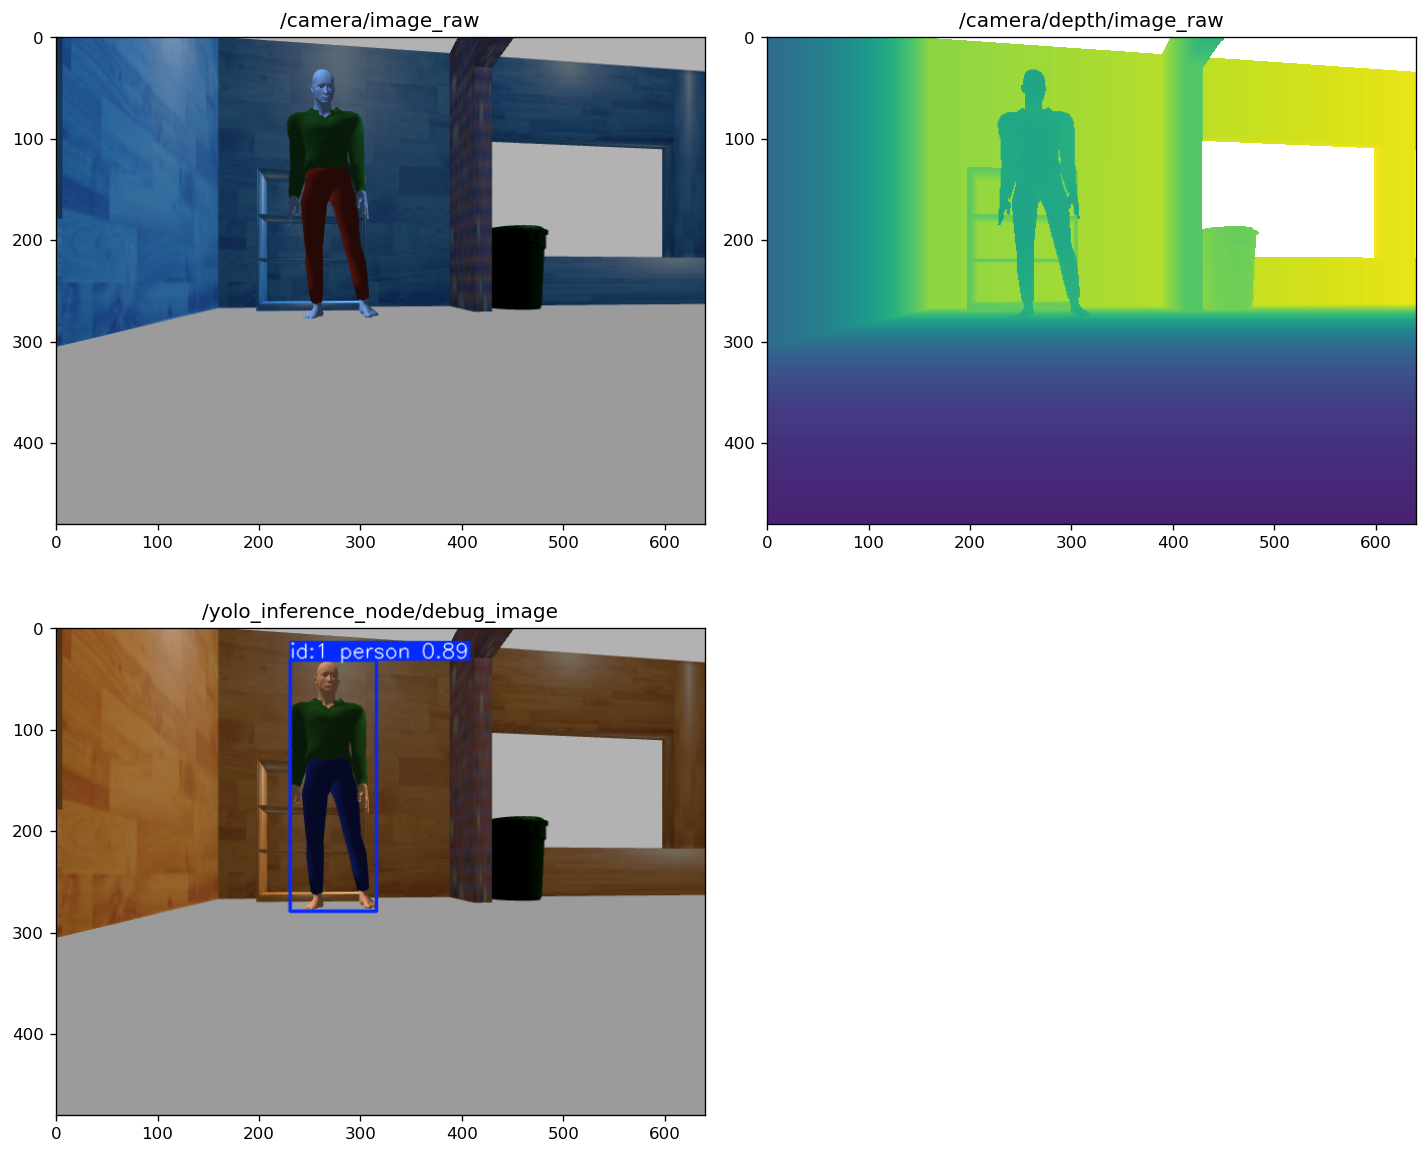

In [4]:
# Quick visualization (optional)
import io
import cv2
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
if image_raw is not None:
    axes[0, 0].imshow(cv2.cvtColor(image_raw, cv2.COLOR_BGR2RGB))
    axes[0, 0].set_title("/camera/image_raw")
if depth_image is not None:
    d = np.asarray(depth_image, dtype=np.float32)
    if depth_image.dtype == np.uint16:
        d = d / 1000.0
    valid = (d > 0) & np.isfinite(d)
    if valid.any():
        axes[0, 1].imshow(d, cmap="viridis", vmin=0, vmax=d[valid].max())
    else:
        axes[0, 1].imshow(d, cmap="viridis")
    axes[0, 1].set_title("/camera/depth/image_raw")
if debug_image is not None:
    axes[1, 0].imshow(cv2.cvtColor(debug_image, cv2.COLOR_BGR2RGB))
    axes[1, 0].set_title("/yolo_inference_node/debug_image")
axes[1, 1].axis("off")
# if detections_2d is not None:
#     axes[1, 1].text(0.1, 0.5, f"detections_2d: {len(detections_2d.detections)} boxes")
# if detections_3d is not None:
#     axes[1, 1].text(0.1, 0.3, f"detections_3d: {len(detections_3d.detections)} boxes")
plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

In [5]:
# Get u, v, w, h from detections_2d (BoundingBox2D center is Pose2D → use .position.x/.position.y)
u = detections_2d.detections[0].bbox.center.position.x
v = detections_2d.detections[0].bbox.center.position.y
w = detections_2d.detections[0].bbox.size_x
h = detections_2d.detections[0].bbox.size_y

In [6]:
# Preprocessing: run pipeline and capture intermediates for visualization
center_x, center_y = int(u), int(v)
size_x, size_y = int(w), int(h)
divisor = 1000
H, W = depth_image.shape[:2]
u_min = max(center_x - size_x // 2, 0)
u_max = min(center_x + size_x // 2, W - 1)
v_min = max(center_y - size_y // 2, 0)
v_max = min(center_y + size_y // 2, H - 1)
depth_roi = depth_image[v_min:v_max, u_min:u_max].copy()
depth_roi_flat = depth_roi.flatten().astype(np.float64)
if depth_image.dtype.kind in ['u', 'i']:
    depth_roi_flat = depth_roi_flat / divisor
valid_mask_flat = (depth_roi_flat > 0) & np.isfinite(depth_roi_flat)
valid_mask_2d = valid_mask_flat.reshape(depth_roi.shape)
roi_h, roi_w = depth_roi.shape
y_grid, x_grid = np.meshgrid(np.arange(roi_h) + v_min, np.arange(roi_w) + u_min, indexing="ij")
pixel_coords = np.column_stack([x_grid.flatten(), y_grid.flatten()])
valid_depths = depth_roi_flat[valid_mask_flat]
valid_coords = pixel_coords[valid_mask_flat]
spatial_weights = depth_processor.DepthProcessor._compute_spatial_weights(
    valid_coords, center_x, center_y, size_x, size_y
)
proc = depth_processor.DepthProcessor(depth_image_units_divisor=divisor)
result = proc.convert_to_3d_bbox(
    depth_image, depth_camera_info, center_x, center_y, size_x, size_y
)
print("Result:", result)

Result: BoundingBox3DData(x=-0.3440176092871224, y=-0.6044480035211196, z=2.5938198166835638, w=0.6130291383570904, h=0.9167466773311739, d=0.34747982025146484)


## Step 1: Preprocess — ROI Cropping & Masking

Extract depth ROI from 2D bbox; valid pixels are > 0 and finite (NaN/zero filtered out).

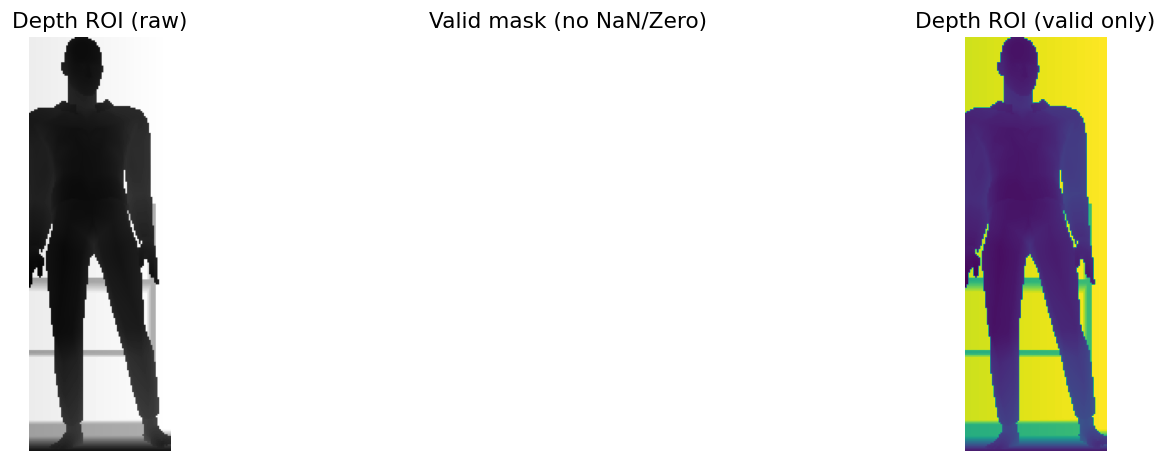

In [7]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
import io

# Larger, clearer text for all plots
plt.rcParams.update({
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 12,
    "xtick.labelsize": 11,
    "ytick.labelsize": 11,
    "legend.fontsize": 11,
})

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
d_show = np.asarray(depth_roi, dtype=np.float32)
if depth_image.dtype == np.uint16:
    d_show = d_show / 1000.0
axes[0].imshow(d_show, cmap="gray")
axes[0].set_title("Depth ROI (raw)")
axes[0].axis("off")
axes[1].imshow(valid_mask_2d.astype(np.uint8), cmap="gray", vmin=0, vmax=1)
axes[1].set_title("Valid mask (no NaN/Zero)")
axes[1].axis("off")
valid_overlay = np.ma.masked_where(~valid_mask_2d, d_show)
axes[2].imshow(d_show, cmap="gray")
axes[2].imshow(valid_overlay, cmap="viridis")
axes[2].set_title("Depth ROI (valid only)")
axes[2].axis("off")
plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

## Step 2: Gaussian Spatial Weighting

Weights by distance to 2D center (Gaussian-like); higher at center to reduce boundary/occlusion noise.

In [8]:
# result and intermediates are computed in the "Preprocessing" cell above
# (proc.convert_to_3d_bbox is called there; no need to run again)

## Step 3: Z Axis (Depth) — Weighted Histogram + Peak, MAD, 2% Trim, P1–P99

Weighted histogram → peak (mode); MAD around peak; Z center from 2% trimmed mean; Z extent from P1–P99.

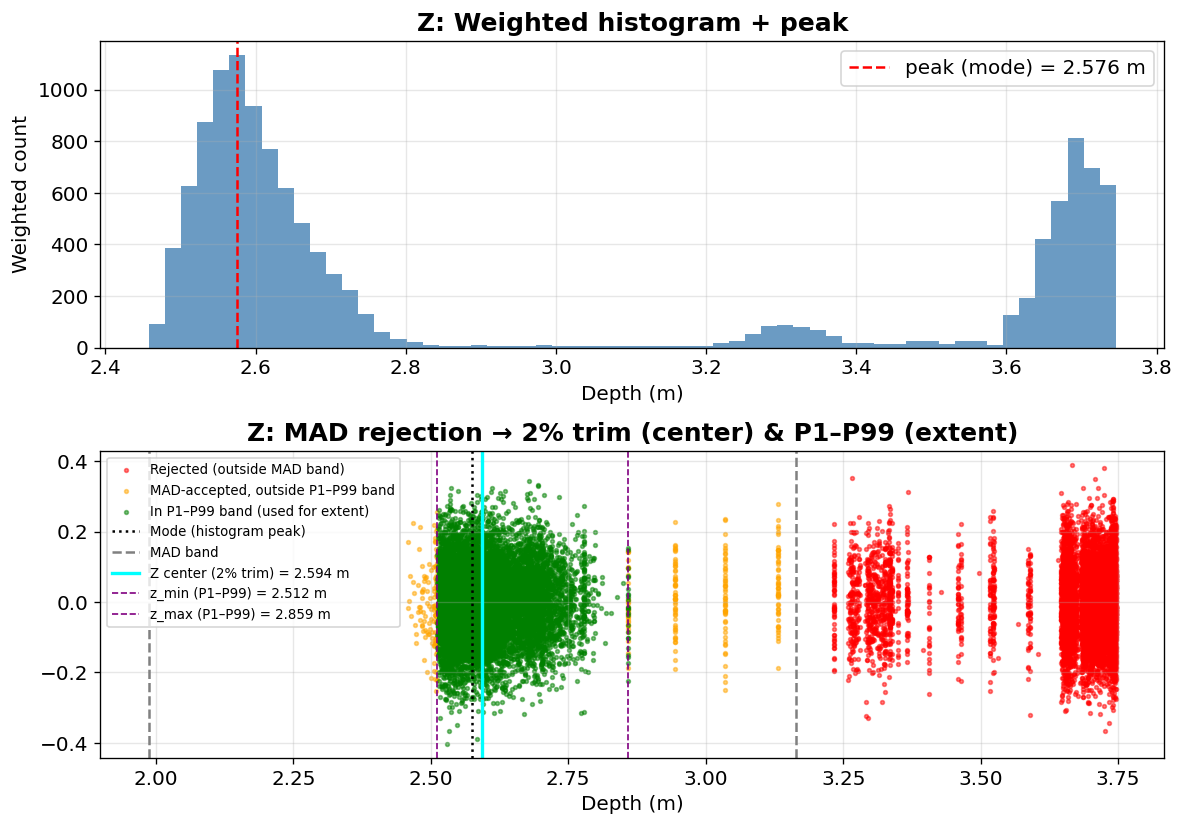

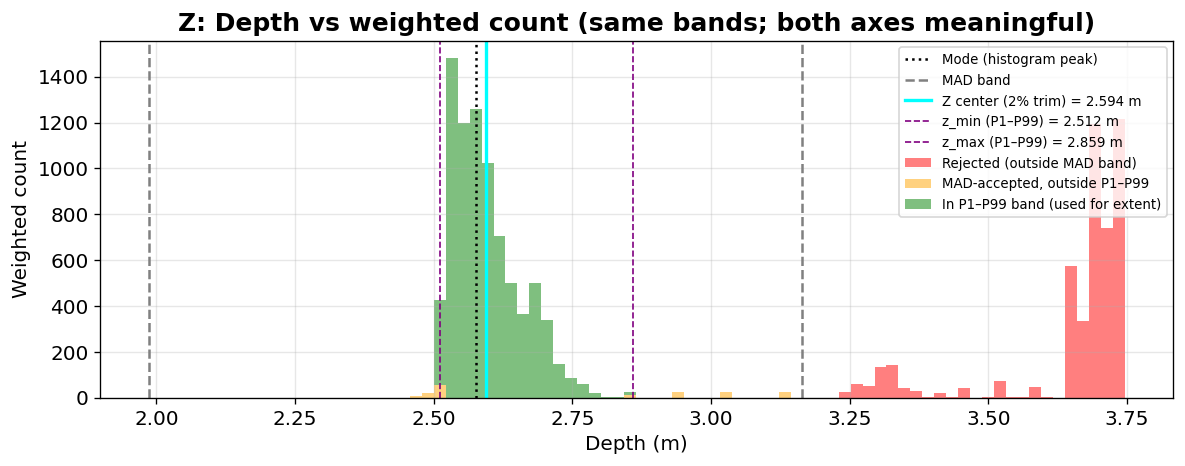

In [9]:
# Replicate Z pipeline steps for visualization
depth_values = valid_depths.copy()
depth_range = np.ptp(depth_values)
n_bins = max(20, min(60, int(depth_range / 0.01))) if np.isfinite(depth_range) and depth_range > 0 else 30
hist, bin_edges = np.histogram(depth_values, bins=n_bins, weights=spatial_weights)
kernel_size = min(5, len(hist) // 4) if len(hist) >= 5 else 1
kernel = np.ones(kernel_size) / kernel_size
hist_smooth = np.convolve(hist, kernel, mode="same") if len(hist) >= 5 else hist
peak_bin_idx = np.argmax(hist_smooth)
mode_depth = (bin_edges[peak_bin_idx] + bin_edges[peak_bin_idx + 1]) / 2
deviations_z = np.abs(depth_values - mode_depth)
mad_z = np.median(deviations_z)
q25, q75 = np.percentile(depth_values, 25), np.percentile(depth_values, 75)
iqr = q75 - q25
if iqr < 0.03:
    threshold_z = np.clip(3.5 * mad_z, 0.08, 0.30)
elif iqr < 0.10:
    threshold_z = np.clip(4.0 * mad_z, 0.12, 0.40)
else:
    threshold_z = np.clip(5.0 * mad_z, 0.15, 0.60)
object_mask_z = deviations_z <= threshold_z

# Apply P1–P99 (and 2% trim for z_center) on Z-accepted points, same as depth_processor
object_depths = depth_values[object_mask_z]
object_weights = spatial_weights[object_mask_z]
min_points = max(6, int(len(depth_values) * 0.15))
if len(object_depths) < min_points:
    sorted_idx_fb = np.argsort(depth_values)
    cumsum_weights_fb = np.cumsum(spatial_weights[sorted_idx_fb])
    cumsum_weights_fb /= cumsum_weights_fb[-1] if cumsum_weights_fb[-1] > 0 else 1.0
    p2_idx = np.searchsorted(cumsum_weights_fb, 0.02)
    p85_idx = np.searchsorted(cumsum_weights_fb, 0.85)
    p2_val = depth_values[sorted_idx_fb[p2_idx]]
    p85_val = depth_values[sorted_idx_fb[p85_idx]]
    object_mask_z = (depth_values >= p2_val) & (depth_values <= p85_val)
    object_depths = depth_values[object_mask_z]
    object_weights = spatial_weights[object_mask_z]
if len(object_depths) == 0:
    object_depths = depth_values
    object_weights = spatial_weights

# Step 3: 2% trim for z_center (exact match to depth_processor)
if np.sum(object_weights) > 0:
    sorted_idx = np.argsort(object_depths)
    sorted_depths = object_depths[sorted_idx]
    sorted_weights = object_weights[sorted_idx]
    cumsum_weights = np.cumsum(sorted_weights)
    cumsum_weights /= cumsum_weights[-1] if cumsum_weights[-1] > 0 else 1.0
    trim_low_idx = np.searchsorted(cumsum_weights, 0.02)
    trim_high_idx = np.searchsorted(cumsum_weights, 0.98)
    if trim_high_idx > trim_low_idx:
        trimmed_depths = sorted_depths[trim_low_idx:trim_high_idx]
        trimmed_weights = sorted_weights[trim_low_idx:trim_high_idx]
        if np.sum(trimmed_weights) > 0:
            z_center_step3 = np.average(trimmed_depths, weights=trimmed_weights)
        else:
            z_center_step3 = np.median(object_depths)
    else:
        z_center_step3 = np.average(object_depths, weights=object_weights)
else:
    z_center_step3 = np.median(object_depths)

# Step 4: P1–P99 for extent (exact match to depth_processor)
sorted_idx = np.argsort(object_depths)
cumsum_weights = np.cumsum(object_weights[sorted_idx])
cumsum_weights /= cumsum_weights[-1] if cumsum_weights[-1] > 0 else 1.0
p1_idx = np.searchsorted(cumsum_weights, 0.01)
p99_idx = np.searchsorted(cumsum_weights, 0.99)
z_min_p199 = object_depths[sorted_idx[p1_idx]]
z_max_p199 = object_depths[sorted_idx[p99_idx]]

# Post-adjustments (same as depth_processor): center in bounds, min depth 2cm
if z_center_step3 < z_min_p199 or z_center_step3 > z_max_p199:
    depth_extent = max(z_max_p199 - z_min_p199, 0.02)
    z_min_p199 = z_center_step3 - depth_extent / 2
    z_max_p199 = z_center_step3 + depth_extent / 2
if (z_max_p199 - z_min_p199) < 0.02:
    half_min = 0.02 / 2
    z_min_p199 = z_center_step3 - half_min
    z_max_p199 = z_center_step3 + half_min

# Mask for final Z range [z_min_p199, z_max_p199] — used in Step 4 (X) and Step 5 (Y)
mask_z_final = (depth_values >= z_min_p199) & (depth_values <= z_max_p199)

fig, axes = plt.subplots(2, 1, figsize=(10, 7))
for ax in axes:
    ax.tick_params(axis="both", labelsize=12)
axes[0].bar((bin_edges[:-1] + bin_edges[1:]) / 2, hist_smooth, width=bin_edges[1]-bin_edges[0], color="steelblue", alpha=0.8)
axes[0].axvline(mode_depth, color="red", ls="--", label=f"peak (mode) = {mode_depth:.3f} m")
axes[0].set_xlabel("Depth (m)", fontsize=12)
axes[0].set_ylabel("Weighted count", fontsize=12)
axes[0].set_title("Z: Weighted histogram + peak", fontsize=15, fontweight="bold")
axes[0].legend(fontsize=12)
axes[0].grid(True, alpha=0.3)
in_z_band = object_mask_z & (depth_values >= z_min_p199) & (depth_values <= z_max_p199)
mad_only = object_mask_z & ~in_z_band
axes[1].scatter(depth_values[~object_mask_z], np.random.randn((~object_mask_z).sum())*0.1, s=5, c="red", alpha=0.5, label="Rejected (outside MAD band)")
axes[1].scatter(depth_values[mad_only], np.random.randn(mad_only.sum())*0.1, s=5, c="orange", alpha=0.5, label="MAD-accepted, outside P1–P99 band")
axes[1].scatter(depth_values[in_z_band], np.random.randn(in_z_band.sum())*0.1, s=5, c="green", alpha=0.5, label="In P1–P99 band (used for extent)")
axes[1].axvline(mode_depth, color="black", ls=":", label="Mode (histogram peak)")
axes[1].axvline(mode_depth - threshold_z, color="gray", ls="--", label="MAD band")
axes[1].axvline(mode_depth + threshold_z, color="gray", ls="--")
axes[1].axvline(z_center_step3, color="cyan", ls="-", lw=2, label=f"Z center (2% trim) = {z_center_step3:.3f} m")
axes[1].axvline(z_min_p199, color="purple", ls="--", lw=1, label=f"z_min (P1–P99) = {z_min_p199:.3f} m")
axes[1].axvline(z_max_p199, color="purple", ls="--", lw=1, label=f"z_max (P1–P99) = {z_max_p199:.3f} m")
axes[1].set_xlabel("Depth (m)", fontsize=12)
axes[1].set_title("Z: MAD rejection → 2% trim (center) & P1–P99 (extent)", fontsize=15, fontweight="bold")
axes[1].legend(loc="upper left", fontsize=8)
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# Option 1: Histogram with both axes meaningful (Depth vs weighted count), same bands and vertical lines
fig2, ax2 = plt.subplots(1, 1, figsize=(10, 4))
ax2.tick_params(axis="both", labelsize=12)
bins = bin_edges
w_rej = spatial_weights[~object_mask_z]
w_mad = spatial_weights[mad_only]
w_in = spatial_weights[in_z_band]
h_rej, _ = np.histogram(depth_values[~object_mask_z], bins=bins, weights=w_rej)
h_mad, _ = np.histogram(depth_values[mad_only], bins=bins, weights=w_mad)
h_in, _ = np.histogram(depth_values[in_z_band], bins=bins, weights=w_in)
x_bin = (bins[:-1] + bins[1:]) / 2
width_bin = bins[1] - bins[0]
ax2.bar(x_bin, h_rej, width=width_bin, color="red", alpha=0.5, label="Rejected (outside MAD band)")
ax2.bar(x_bin, h_mad, width=width_bin, bottom=h_rej, color="orange", alpha=0.5, label="MAD-accepted, outside P1–P99")
ax2.bar(x_bin, h_in, width=width_bin, bottom=h_rej + h_mad, color="green", alpha=0.5, label="In P1–P99 band (used for extent)")
ax2.axvline(mode_depth, color="black", ls=":", label="Mode (histogram peak)")
ax2.axvline(mode_depth - threshold_z, color="gray", ls="--", label="MAD band")
ax2.axvline(mode_depth + threshold_z, color="gray", ls="--")
ax2.axvline(z_center_step3, color="cyan", ls="-", lw=2, label=f"Z center (2% trim) = {z_center_step3:.3f} m")
ax2.axvline(z_min_p199, color="purple", ls="--", lw=1, label=f"z_min (P1–P99) = {z_min_p199:.3f} m")
ax2.axvline(z_max_p199, color="purple", ls="--", lw=1, label=f"z_max (P1–P99) = {z_max_p199:.3f} m")
ax2.set_xlabel("Depth (m)", fontsize=12)
ax2.set_ylabel("Weighted count", fontsize=12)
ax2.set_title("Z: Depth vs weighted count (same bands; both axes meaningful)", fontsize=15, fontweight="bold")
ax2.legend(loc="upper right", fontsize=8)
ax2.grid(True, alpha=0.3)
plt.tight_layout()
buf2 = io.BytesIO()
fig2.savefig(buf2, format="png", dpi=120, bbox_inches="tight")
plt.close(fig2)
buf2.seek(0)
display(IPImage(data=buf2.read()))

## Step 4: X Axis (Width) — Inverse projection, adaptive MAD, 5% trim, P3–P97

(u,Z) → x via K; adaptive threshold (4.0×MAD if depth_std high, else 4.5×MAD); center = 5% trimmed mean; extent = P3–P97.

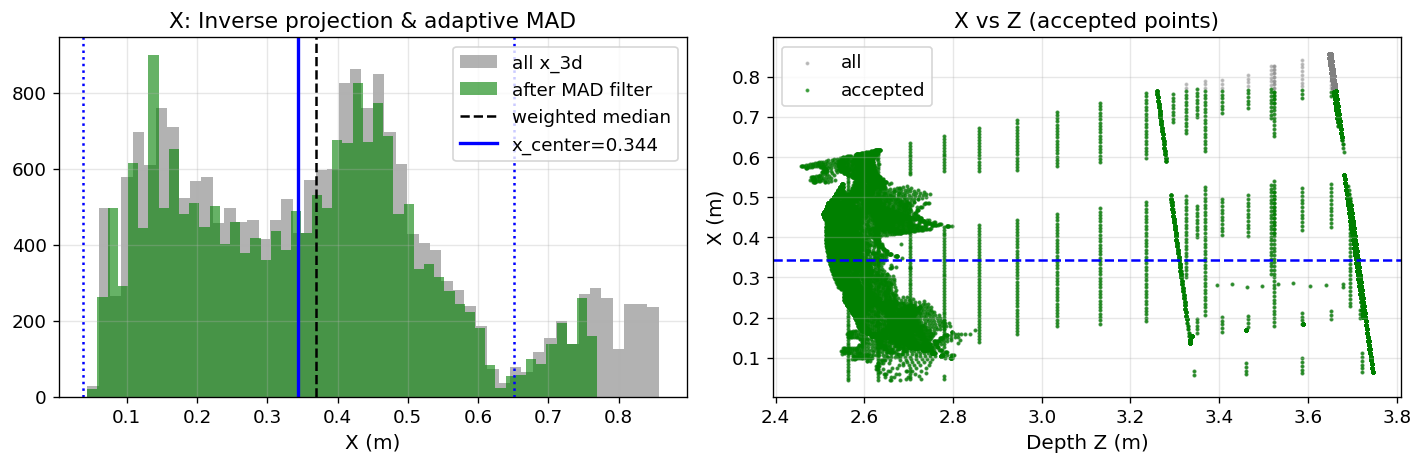

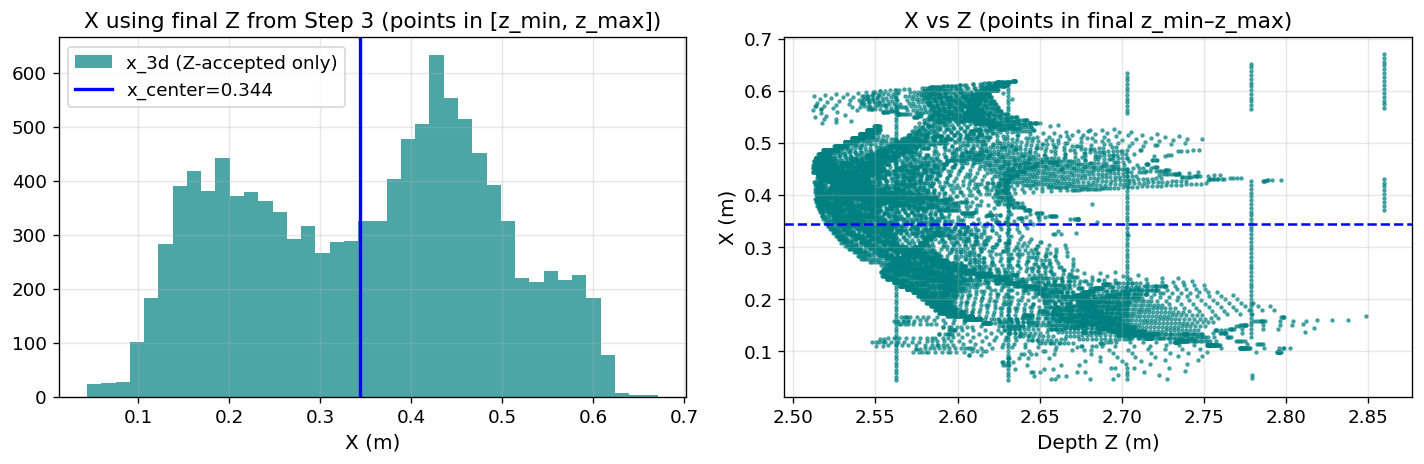

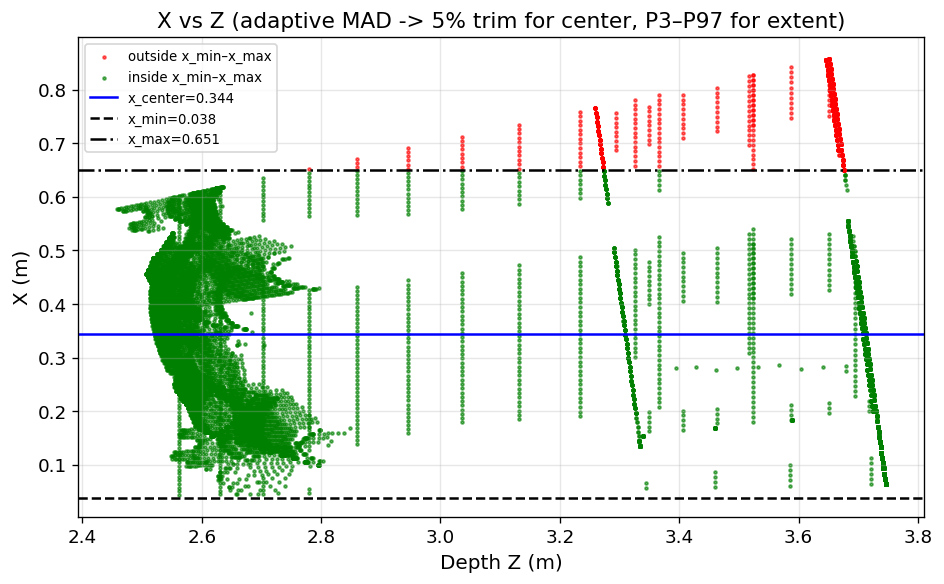

In [10]:
# X-axis: inverse projection and MAD filtering (same logic as _compute_width_bounds)
k = depth_camera_info.k
px, fx = k[2], k[0]
# Camera convention: negate X so horizontal direction matches image / expected (fixes "X flipped" in Step 5 / 3D view)
x_3d = -valid_depths * (valid_coords[:, 0] - px) / fx
x_median = np.median(x_3d)
sorted_idx = np.argsort(x_3d)
sw_cum = np.cumsum(spatial_weights[sorted_idx]) / (np.sum(spatial_weights) + 1e-12)
median_idx = np.searchsorted(sw_cum, 0.5)
x_median_w = x_3d[sorted_idx[median_idx]]
deviations_x = np.abs(x_3d - x_median_w)
mad_x = np.median(deviations_x)
depth_std = np.std(valid_depths)
threshold_x = np.clip(4.0 * mad_x, 0.06, 0.40) if depth_std > 0.15 else np.clip(4.5 * mad_x, 0.08, 0.50)
valid_mask_x = deviations_x <= threshold_x
filtered_x = x_3d[valid_mask_x]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(x_3d, bins=50, color="gray", alpha=0.6, label="all x_3d")
axes[0].hist(filtered_x, bins=50, color="green", alpha=0.6, label="after MAD filter")
axes[0].axvline(x_median_w, color="black", ls="--", label="weighted median")
if result:
    axes[0].axvline(-result.x, color="blue", lw=2, label=f"x_center={-result.x:.3f}")
    axes[0].axvline(-result.x - result.w/2, color="blue", ls=":")
    axes[0].axvline(-result.x + result.w/2, color="blue", ls=":")
axes[0].set_xlabel("X (m)")
axes[0].set_title("X: Inverse projection & adaptive MAD")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].scatter(valid_depths, x_3d, s=2, c="gray", alpha=0.4, label="all")
axes[1].scatter(valid_depths[valid_mask_x], filtered_x, s=2, c="green", alpha=0.6, label="accepted")
if result:
    axes[1].axhline(-result.x, color="blue", ls="--")
axes[1].set_xlabel("Depth Z (m)")
axes[1].set_ylabel("X (m)")
axes[1].set_title("X vs Z (accepted points)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# --- Using final Z from Step 3 (z_min–z_max): X restricted to points in [z_min_p199, z_max_p199] ---
depths_z = valid_depths[mask_z_final]
coords_z = valid_coords[mask_z_final]
weights_z = spatial_weights[mask_z_final]
x_3d_z = -depths_z * (coords_z[:, 0] - px) / fx  # same X flip as x_3d
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4))
ax2[0].hist(x_3d_z, bins=40, color="teal", alpha=0.7, label="x_3d (Z-accepted only)")
if result:
    ax2[0].axvline(-result.x, color="blue", lw=2, label=f"x_center={-result.x:.3f}")
ax2[0].set_xlabel("X (m)")
ax2[0].set_title("X using final Z from Step 3 (points in [z_min, z_max])")
ax2[0].legend()
ax2[0].grid(True, alpha=0.3)
ax2[1].scatter(depths_z, x_3d_z, s=3, c="teal", alpha=0.6)
if result:
    ax2[1].axhline(-result.x, color="blue", ls="--")
ax2[1].set_xlabel("Depth Z (m)")
ax2[1].set_ylabel("X (m)")
ax2[1].set_title("X vs Z (points in final z_min–z_max)")
ax2[1].grid(True, alpha=0.3)
plt.tight_layout()
buf2 = io.BytesIO()
fig2.savefig(buf2, format="png", dpi=120, bbox_inches="tight")
plt.close(fig2)
buf2.seek(0)
display(IPImage(data=buf2.read()))

# Separate figure: X vs Z (all points), green = inside [x_min, x_max], red = outside
fig3, ax3 = plt.subplots(1, 1, figsize=(8, 5))
if result:
    x_min_display = -result.x - result.w / 2
    x_max_display = -result.x + result.w / 2
    inside_x_bounds = (x_3d >= x_min_display) & (x_3d <= x_max_display)
    ax3.scatter(valid_depths[~inside_x_bounds], x_3d[~inside_x_bounds], s=3, c="red", alpha=0.6, label="outside x_min–x_max")
    ax3.scatter(valid_depths[inside_x_bounds], x_3d[inside_x_bounds], s=3, c="green", alpha=0.6, label="inside x_min–x_max")
    x_center_display = -result.x
    ax3.axhline(x_center_display, color="blue", ls="-", lw=1.5, label=f"x_center={x_center_display:.3f}")
    ax3.axhline(x_min_display, color="black", ls="--", lw=1.5, label=f"x_min={x_min_display:.3f}")
    ax3.axhline(x_max_display, color="black", ls="-.", lw=1.5, label=f"x_max={x_max_display:.3f}")
else:
    ax3.scatter(valid_depths, x_3d, s=3, c="gray", alpha=0.6, label="all (no bbox)")
ax3.set_xlabel("Depth Z (m)")
ax3.set_ylabel("X (m)")
ax3.set_title("X vs Z (adaptive MAD -> 5% trim for center, P3–P97 for extent)")
ax3.legend(loc="best", fontsize=8)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
buf3 = io.BytesIO()
fig3.savefig(buf3, format="png", dpi=120, bbox_inches="tight")
plt.close(fig3)
buf3.seek(0)
display(IPImage(data=buf3.read()))

## Step 5: Y Axis (Height) — Inverse projection, fixed 4.5×MAD, 5% trim, P3–P97

(v,Z) → y via K; fixed 4.5×MAD threshold; center = 5% trimmed mean; extent = P3–P97.

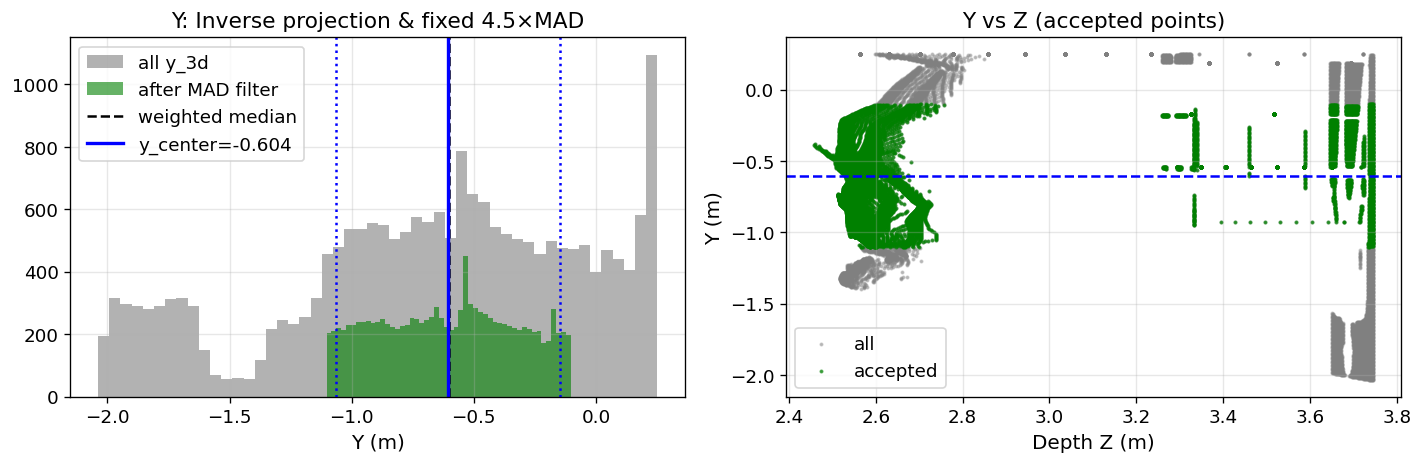

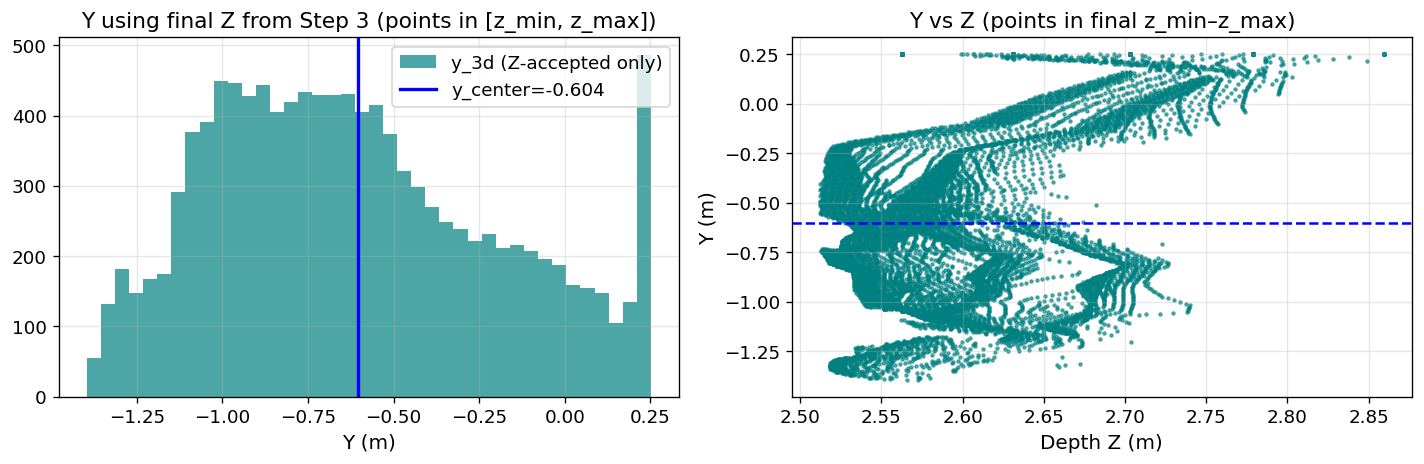

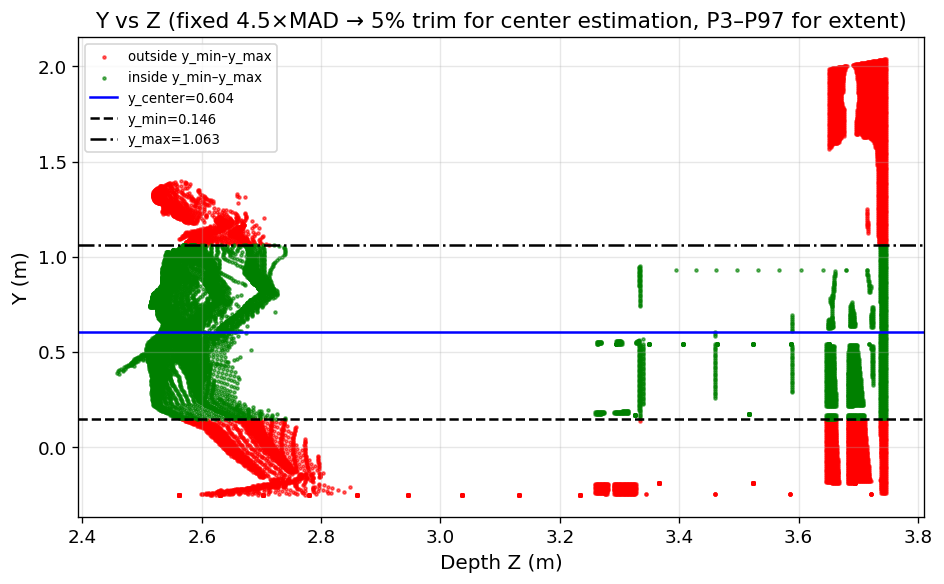

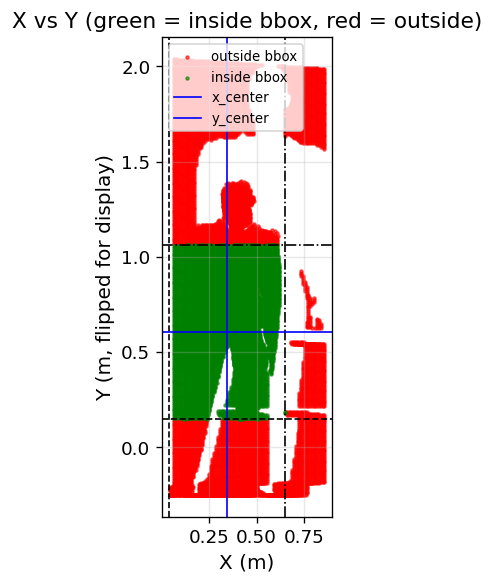

In [11]:
# Y-axis: inverse projection and MAD filtering (fixed 4.5×MAD)
py, fy = k[5], k[4]
y_3d = valid_depths * (valid_coords[:, 1] - py) / fy
sorted_idx_y = np.argsort(y_3d)
sw_cum_y = np.cumsum(spatial_weights[sorted_idx_y]) / (np.sum(spatial_weights) + 1e-12)
median_idx_y = np.searchsorted(sw_cum_y, 0.5)
y_median_w = y_3d[sorted_idx_y[median_idx_y]]
deviations_y = np.abs(y_3d - y_median_w)
mad_y = np.median(deviations_y)
threshold_y = np.clip(4.5 * mad_y, 0.06, 0.50)
valid_mask_y = deviations_y <= threshold_y
filtered_y = y_3d[valid_mask_y]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(y_3d, bins=50, color="gray", alpha=0.6, label="all y_3d")
axes[0].hist(filtered_y, bins=50, color="green", alpha=0.6, label="after MAD filter")
axes[0].axvline(y_median_w, color="black", ls="--", label="weighted median")
if result:
    axes[0].axvline(result.y, color="blue", lw=2, label=f"y_center={result.y:.3f}")
    axes[0].axvline(result.y - result.h/2, color="blue", ls=":")
    axes[0].axvline(result.y + result.h/2, color="blue", ls=":")
axes[0].set_xlabel("Y (m)")
axes[0].set_title("Y: Inverse projection & fixed 4.5×MAD")
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].scatter(valid_depths, y_3d, s=2, c="gray", alpha=0.4, label="all")
axes[1].scatter(valid_depths[valid_mask_y], filtered_y, s=2, c="green", alpha=0.6, label="accepted")
if result:
    axes[1].axhline(result.y, color="blue", ls="--")
axes[1].set_xlabel("Depth Z (m)")
axes[1].set_ylabel("Y (m)")
axes[1].set_title("Y vs Z (accepted points)")
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# --- Using final Z from Step 3 (z_min–z_max): Y restricted to points in [z_min_p199, z_max_p199] ---
depths_z_y = valid_depths[mask_z_final]
coords_z_y = valid_coords[mask_z_final]
y_3d_z = depths_z_y * (coords_z_y[:, 1] - py) / fy
fig2, ax2 = plt.subplots(1, 2, figsize=(12, 4))
ax2[0].hist(y_3d_z, bins=40, color="teal", alpha=0.7, label="y_3d (Z-accepted only)")
if result:
    ax2[0].axvline(result.y, color="blue", lw=2, label=f"y_center={result.y:.3f}")
ax2[0].set_xlabel("Y (m)")
ax2[0].set_title("Y using final Z from Step 3 (points in [z_min, z_max])")
ax2[0].legend()
ax2[0].grid(True, alpha=0.3)
ax2[1].scatter(depths_z_y, y_3d_z, s=3, c="teal", alpha=0.6)
if result:
    ax2[1].axhline(result.y, color="blue", ls="--")
ax2[1].set_xlabel("Depth Z (m)")
ax2[1].set_ylabel("Y (m)")
ax2[1].set_title("Y vs Z (points in final z_min–z_max)")
ax2[1].grid(True, alpha=0.3)
plt.tight_layout()
buf2 = io.BytesIO()
fig2.savefig(buf2, format="png", dpi=120, bbox_inches="tight")
plt.close(fig2)
buf2.seek(0)
display(IPImage(data=buf2.read()))

# Separate figure: Y vs Z (all points), green = inside [y_min, y_max], red = outside. Camera convention: flip Y for display.
fig3, ax3 = plt.subplots(1, 1, figsize=(8, 5))
y_3d_display_z = -y_3d  # flip Y so plot "up" = image "up"
if result:
    y_min_display = result.y - result.h / 2
    y_max_display = result.y + result.h / 2
    inside_y_bounds = (y_3d >= y_min_display) & (y_3d <= y_max_display)
    ax3.scatter(valid_depths[~inside_y_bounds], y_3d_display_z[~inside_y_bounds], s=3, c="red", alpha=0.6, label="outside y_min–y_max")
    ax3.scatter(valid_depths[inside_y_bounds], y_3d_display_z[inside_y_bounds], s=3, c="green", alpha=0.6, label="inside y_min–y_max")
    y_center_display = -result.y
    y_min_plot = -result.y - result.h / 2
    y_max_plot = -result.y + result.h / 2
    ax3.axhline(y_center_display, color="blue", ls="-", lw=1.5, label=f"y_center={y_center_display:.3f}")
    ax3.axhline(y_min_plot, color="black", ls="--", lw=1.5, label=f"y_min={y_min_plot:.3f}")
    ax3.axhline(y_max_plot, color="black", ls="-.", lw=1.5, label=f"y_max={y_max_plot:.3f}")
else:
    ax3.scatter(valid_depths, y_3d_display_z, s=3, c="gray", alpha=0.6, label="all (no bbox)")
ax3.set_xlabel("Depth Z (m)")
ax3.set_ylabel("Y (m)")
ax3.set_title("Y vs Z (fixed 4.5×MAD → 5% trim for center estimation, P3–P97 for extent)")
ax3.legend(loc="best", fontsize=8)
ax3.grid(True, alpha=0.3)
plt.tight_layout()
buf3 = io.BytesIO()
fig3.savefig(buf3, format="png", dpi=120, bbox_inches="tight")
plt.close(fig3)
buf3.seek(0)
display(IPImage(data=buf3.read()))

# Separate figure: X vs Y (all points), green = inside bbox, red = outside. Camera convention: flip Y so plot "up" = image "up".
fig4, ax4 = plt.subplots(1, 1, figsize=(8, 5))
y_3d_display = -y_3d  # flip Y for display (same as 3D view)
if result:
    x_min_display = -result.x - result.w / 2
    x_max_display = -result.x + result.w / 2
    y_min_display = result.y - result.h / 2
    y_max_display = result.y + result.h / 2
    inside_xy = ((x_3d >= x_min_display) & (x_3d <= x_max_display) &
                 (y_3d >= y_min_display) & (y_3d <= y_max_display))
    ax4.scatter(x_3d[~inside_xy], y_3d_display[~inside_xy], s=3, c="red", alpha=0.6, label="outside bbox")
    ax4.scatter(x_3d[inside_xy], y_3d_display[inside_xy], s=3, c="green", alpha=0.6, label="inside bbox")
    ax4.axvline(-result.x, color="blue", ls="-", lw=1, label="x_center")
    ax4.axvline(x_min_display, color="black", ls="--", lw=1)
    ax4.axvline(x_max_display, color="black", ls="-.", lw=1)
    ax4.axhline(-result.y, color="blue", ls="-", lw=1, label="y_center")
    ax4.axhline(-result.y - result.h / 2, color="black", ls="--", lw=1)
    ax4.axhline(-result.y + result.h / 2, color="black", ls="-.", lw=1)
else:
    ax4.scatter(x_3d, y_3d_display, s=3, c="gray", alpha=0.6, label="all (no bbox)")
ax4.set_xlabel("X (m)")
ax4.set_ylabel("Y (m, flipped for display)")
ax4.set_title("X vs Y (green = inside bbox, red = outside)")
ax4.legend(loc="best", fontsize=8)
ax4.grid(True, alpha=0.3)
ax4.set_aspect("equal")
plt.tight_layout()
buf4 = io.BytesIO()
fig4.savefig(buf4, format="png", dpi=120, bbox_inches="tight")
plt.close(fig4)
buf4.seek(0)
display(IPImage(data=buf4.read()))

## Final: X, Y, Z accepted points (one view)

Same point set (Z-accepted from Step 3) shown in Z–X, Z–Y, and X–Y.

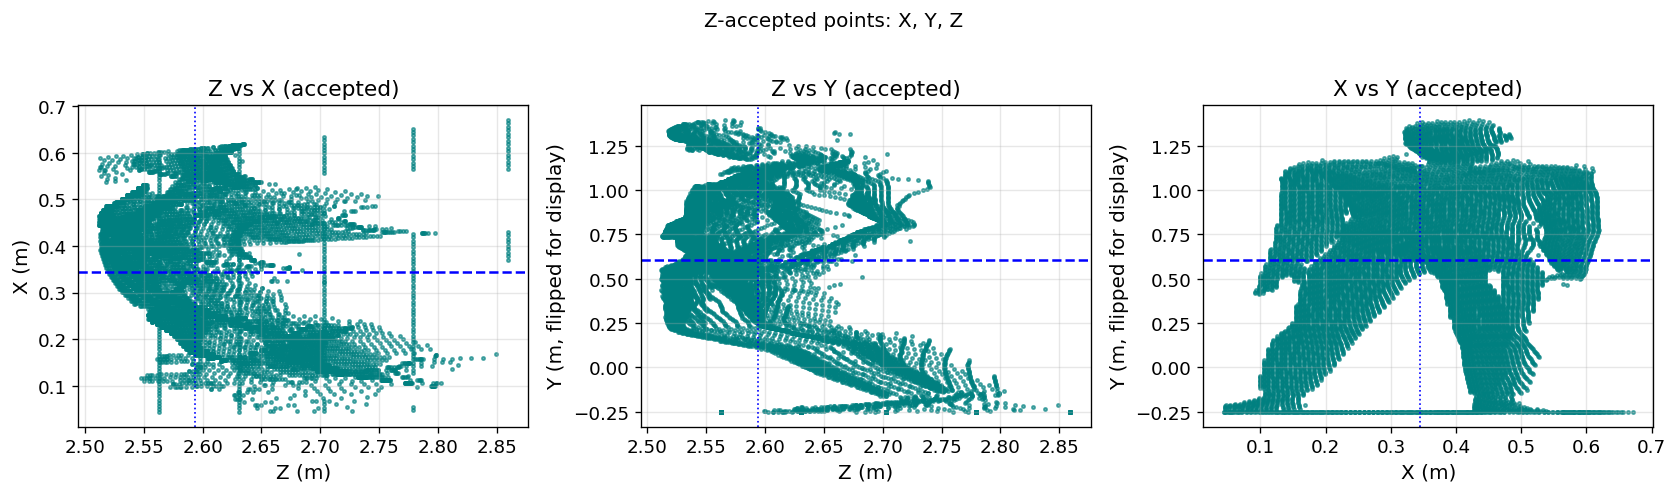

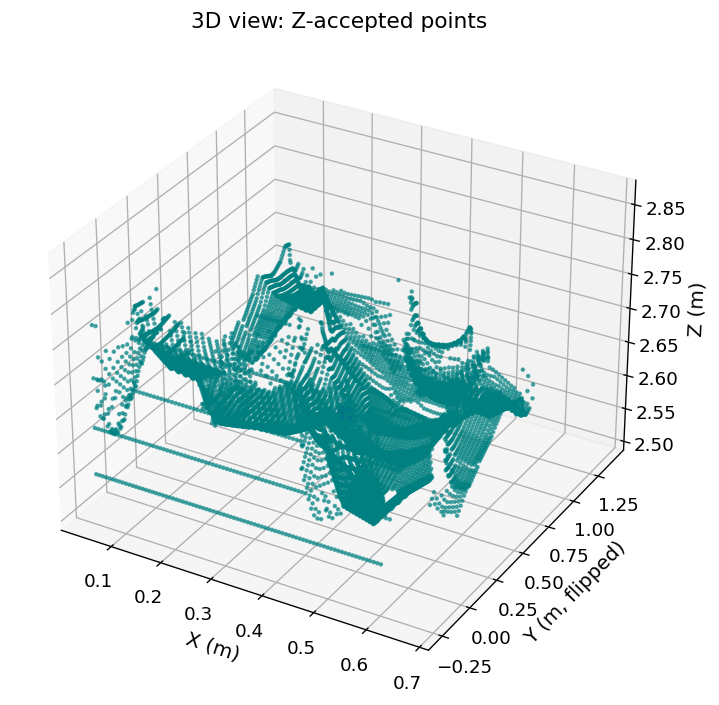

In [12]:
# Final Z range points [z_min_p199, z_max_p199]: one subset for X, Y, Z
# Camera convention: negate X (same as Step 4); flip Y for display so image "up" = plot "up".
z_acc = valid_depths[mask_z_final]
c_acc = valid_coords[mask_z_final]
x_acc = -z_acc * (c_acc[:, 0] - px) / fx  # same X flip as Step 4
y_acc = z_acc * (c_acc[:, 1] - py) / fy
y_acc_display = -y_acc  # flip Y so vertical matches image

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].scatter(z_acc, x_acc, s=4, c="teal", alpha=0.6)
axes[0].set_xlabel("Z (m)")
axes[0].set_ylabel("X (m)")
axes[0].set_title("Z vs X (accepted)")
if result:
    axes[0].axhline(-result.x, color="blue", ls="--", lw=1.5)
    axes[0].axvline(result.z, color="blue", ls=":", lw=1)
axes[0].grid(True, alpha=0.3)

axes[1].scatter(z_acc, y_acc_display, s=4, c="teal", alpha=0.6)
axes[1].set_xlabel("Z (m)")
axes[1].set_ylabel("Y (m, flipped for display)")
axes[1].set_title("Z vs Y (accepted)")
if result:
    axes[1].axhline(-result.y, color="blue", ls="--", lw=1.5)
    axes[1].axvline(result.z, color="blue", ls=":", lw=1)
axes[1].grid(True, alpha=0.3)

axes[2].scatter(x_acc, y_acc_display, s=4, c="teal", alpha=0.6)
axes[2].set_xlabel("X (m)")
axes[2].set_ylabel("Y (m, flipped for display)")
axes[2].set_title("X vs Y (accepted)")
if result:
    axes[2].axhline(-result.y, color="blue", ls="--", lw=1.5)
    axes[2].axvline(-result.x, color="blue", ls=":", lw=1)
axes[2].grid(True, alpha=0.3)

plt.suptitle("Z-accepted points: X, Y, Z", fontsize=12, y=1.02)
plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))

# 3D view: same Y flip so "up" in image is "up" in 3D
from mpl_toolkits.mplot3d import Axes3D
fig3d = plt.figure(figsize=(8, 6))
ax3d = fig3d.add_subplot(111, projection="3d")
ax3d.scatter(x_acc, -y_acc, z_acc, s=3, c="teal", alpha=0.6)
ax3d.set_xlabel("X (m)")
ax3d.set_ylabel("Y (m, flipped)")
ax3d.set_zlabel("Z (m)")
ax3d.set_title("3D view: Z-accepted points")
if result:
    ax3d.scatter([-result.x], [-result.y], [result.z], s=80, c="blue", marker="o", label="bbox center")
plt.tight_layout()
buf3d = io.BytesIO()
fig3d.savefig(buf3d, format="png", dpi=120, bbox_inches="tight")
plt.close(fig3d)
buf3d.seek(0)
display(IPImage(data=buf3d.read()))

## Summary: 3D bounding box result

Final box from the pipeline (center x,y,z and size w,h,d in meters).

In [13]:
if result:
    print(f"3D BBox center (x,y,z) = ({result.x:.3f}, {result.y:.3f}, {result.z:.3f}) m")
    print(f"3D BBox size (w,h,d)   = ({result.w:.3f}, {result.h:.3f}, {result.d:.3f}) m")
else:
    print("No result (pipeline returned None).")

3D BBox center (x,y,z) = (-0.344, -0.604, 2.594) m
3D BBox size (w,h,d)   = (0.613, 0.917, 0.347) m


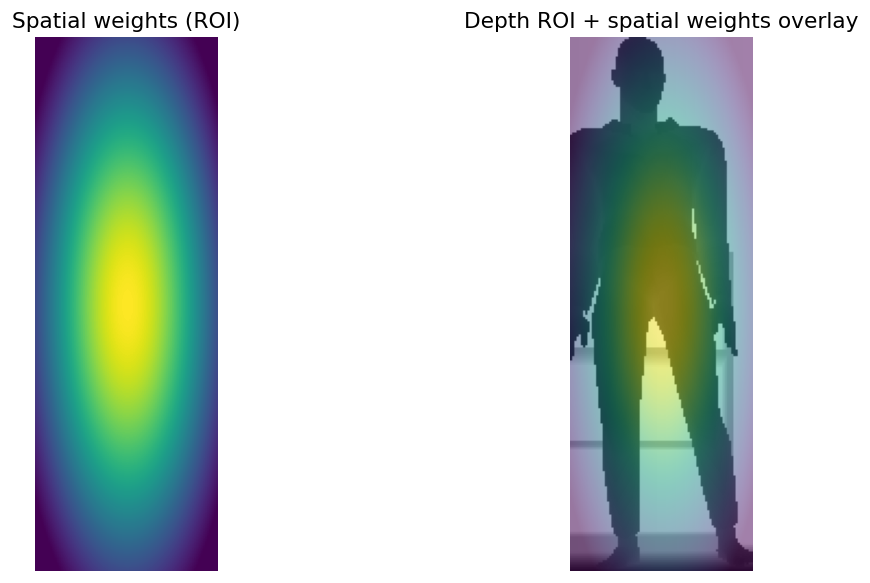

In [14]:
# Visualize spatial_weights map (same formula as depth_processor._compute_spatial_weights)
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import display, Image as IPImage
import io

center_x, center_y = int(u), int(v)
size_x, size_y = int(w), int(h)
H, W = depth_image.shape[:2]
u_min = max(center_x - size_x // 2, 0)
u_max = min(center_x + size_x // 2, W - 1)
v_min = max(center_y - size_y // 2, 0)
v_max = min(center_y + size_y // 2, H - 1)

roi_h, roi_w = v_max - v_min, u_max - u_min
y_grid, x_grid = np.meshgrid(
    np.arange(roi_h) + v_min, np.arange(roi_w) + u_min, indexing="ij"
)
pixel_coords = np.column_stack([x_grid.flatten(), y_grid.flatten()])
spatial_weights_1d = depth_processor.DepthProcessor._compute_spatial_weights(
    pixel_coords, center_x, center_y, size_x, size_y
)
spatial_weights_map = spatial_weights_1d.reshape(roi_h, roi_w)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].imshow(spatial_weights_map, cmap="viridis", vmin=0.3, vmax=1.0)
axes[0].set_title("Spatial weights (ROI)")
axes[0].axis("off")

# Overlay on depth ROI for context
depth_roi = np.asarray(depth_image[v_min:v_max, u_min:u_max], dtype=np.float32)
if depth_roi.dtype == np.uint16:
    depth_roi = depth_roi / 1000.0
valid = (depth_roi > 0) & np.isfinite(depth_roi)
axes[1].imshow(depth_roi, cmap="gray")
axes[1].imshow(spatial_weights_map, cmap="viridis", alpha=0.5, vmin=0.3, vmax=1.0)
axes[1].set_title("Depth ROI + spatial weights overlay")
axes[1].axis("off")
plt.tight_layout()
buf = io.BytesIO()
fig.savefig(buf, format="png", dpi=120, bbox_inches="tight")
plt.close(fig)
buf.seek(0)
display(IPImage(data=buf.read()))